# Breast Cancer Wisconsin (Diagnostic): Classification Analysis

## Goal

Predict whether a breast tumor is **malignant** or **benign** from 30 numeric
features computed from a digitized image of a fine needle aspirate (FNA) of
a breast mass, the classic *Breast Cancer Wisconsin (Diagnostic)* data set
(569 samples). The notebook covers exploratory analysis, preprocessing,
model comparison across five classifiers, hyperparameter tuning, and
evaluation on a held-out test set, with an eye on the metric that matters
most in a diagnostic setting: catching malignant cases.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, roc_auc_score)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42

## Load the data set

In [2]:
df = pd.read_csv("breast_cancer.csv")
print("Shape:", df.shape)
df.head()

Shape: (569, 32)


,id,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,2,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,3,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,4,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,5,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


The `diagnosis` column holds the string labels `M` (malignant) and `B`
(benign). It's mapped to a numeric target with **malignant = 1**, since in a
diagnostic setting the "positive" class should be the one you don't want to
miss. The `id` column is just a row identifier and carries no predictive
signal, so it's dropped before modeling.

In [3]:
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})
df = df.drop(columns=["id"])

df.to_csv("breast_cancer_clean.csv", index=False)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


# Exploratory Data Analysis

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [6]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")
print()
print("Exact duplicate rows:", df.duplicated().sum())

Missing values per column:
0 total missing values

Exact duplicate rows: 0


No missing values and no duplicate rows: the data set is clean out of the box.

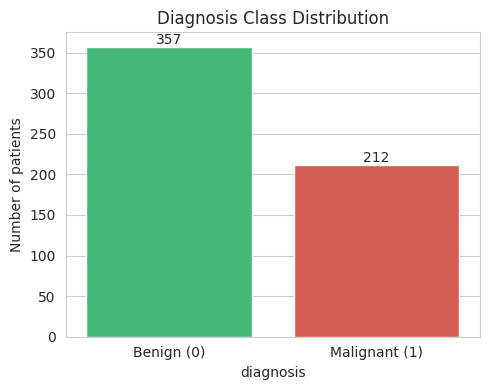

Benign: 357 (62.7%)   Malignant: 212 (37.3%)


In [7]:
counts = df["diagnosis"].value_counts().sort_index()
pct = df["diagnosis"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(5, 4))
ax = sns.countplot(x="diagnosis", data=df, hue="diagnosis",
                    palette=["#2ecc71", "#e74c3c"], legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Benign (0)", "Malignant (1)"])
ax.set_title("Diagnosis Class Distribution")
ax.set_ylabel("Number of patients")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

print(f"Benign: {counts[0]} ({pct[0]:.1f}%)   Malignant: {counts[1]} ({pct[1]:.1f}%)")

The classes are moderately imbalanced (roughly 63% benign, 37%
malignant). Not severe enough to need resampling, but accuracy alone won't
tell the full story, so precision, recall, F1, and ROC-AUC are tracked
throughout: a missed malignant case is a far more expensive mistake than a
false alarm.

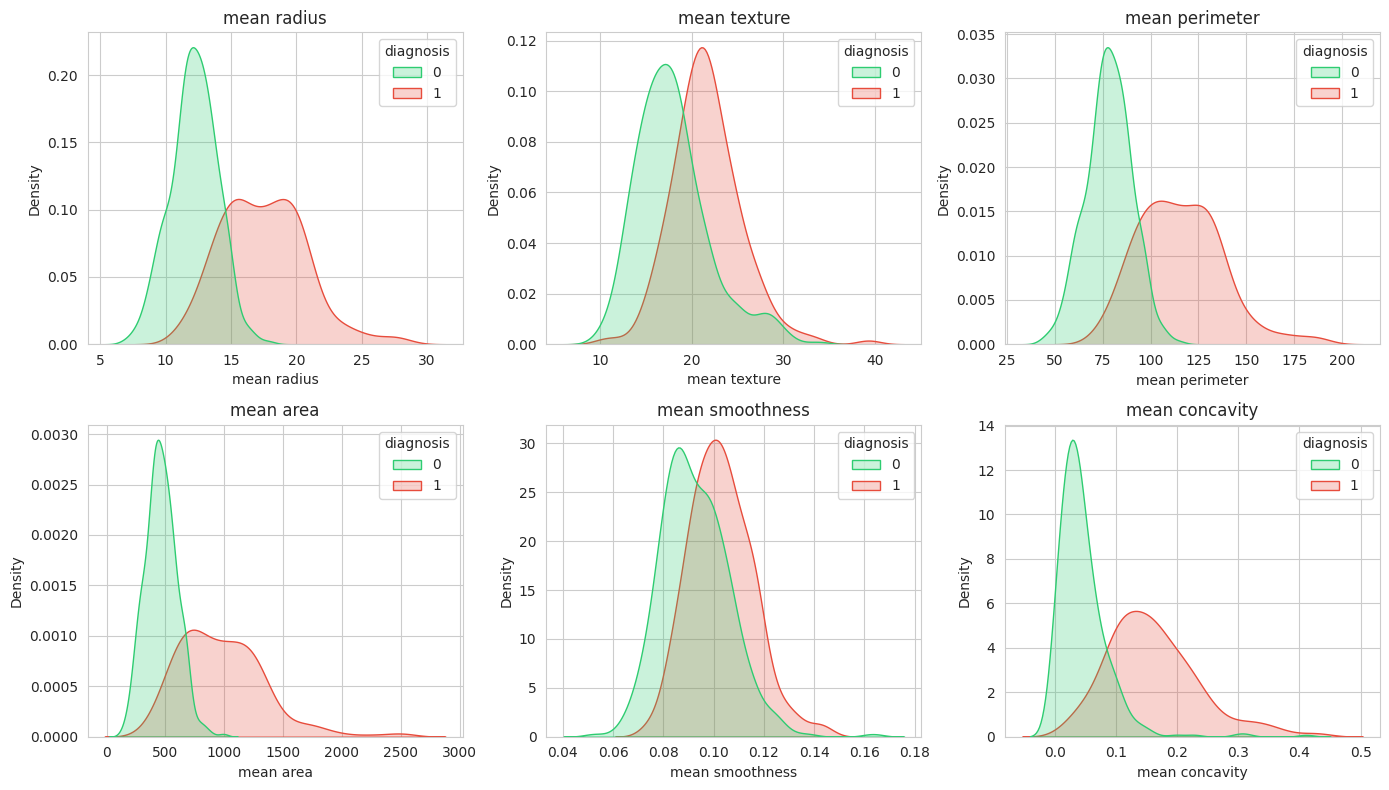

In [8]:
key_features = ["mean radius", "mean texture", "mean perimeter",
                "mean area", "mean smoothness", "mean concavity"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flatten(), key_features):
    sns.kdeplot(data=df, x=feat, hue="diagnosis", fill=True, ax=ax,
                palette=["#2ecc71", "#e74c3c"], common_norm=False)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

Malignant tumors tend to be larger and more irregular: higher mean
radius, perimeter, area, and concavity than benign ones, with fairly clean
separation on several features. That's a good early sign that
margin-based and tree-based classifiers should do well here.

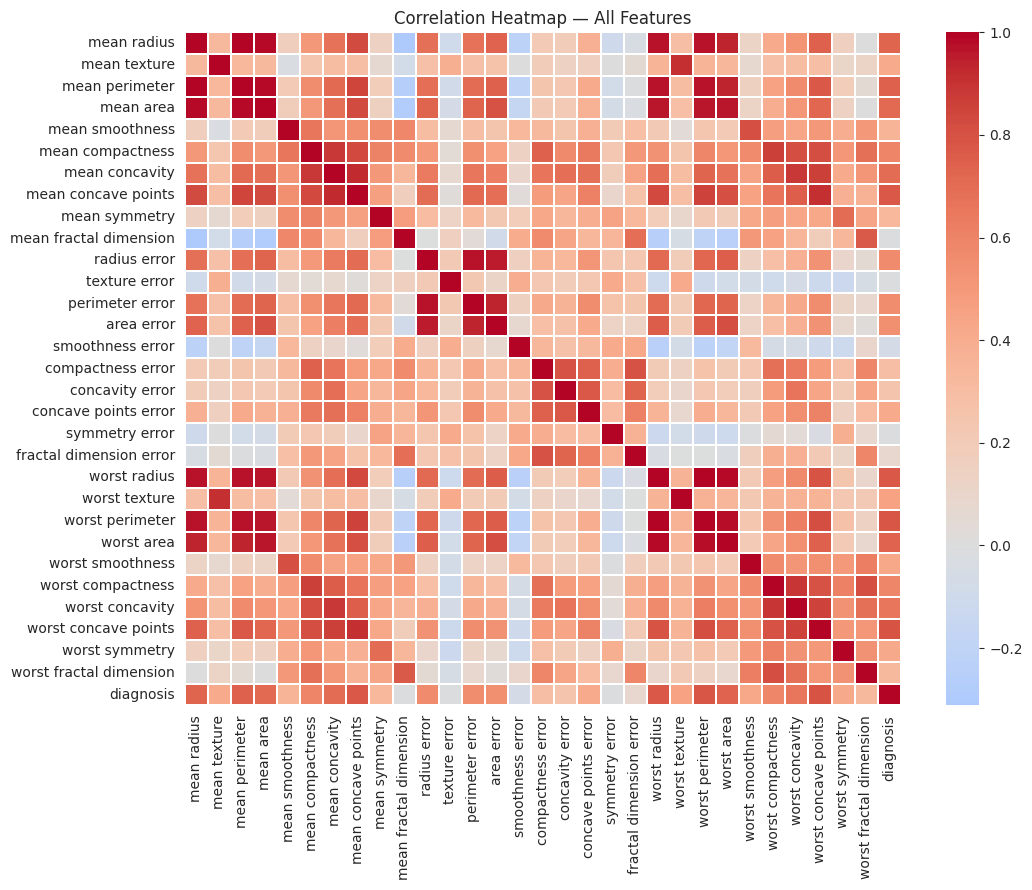

In [9]:
plt.figure(figsize=(11, 9))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3,
            xticklabels=True, yticklabels=True)
plt.title("Correlation Heatmap: All Features")
plt.tight_layout()
plt.show()

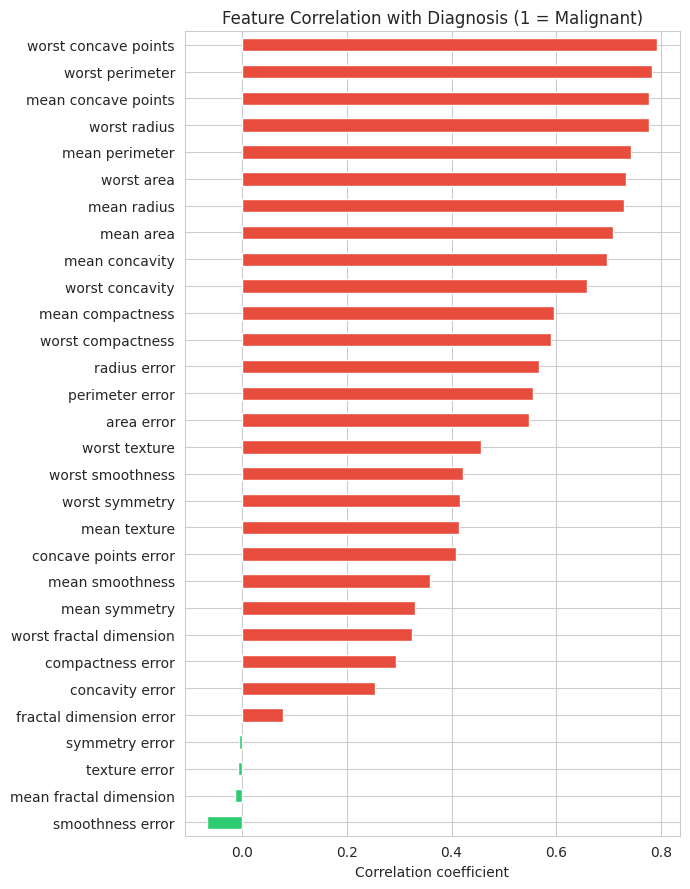

worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
Name: diagnosis, dtype: float64

In [10]:
target_corr = corr["diagnosis"].drop("diagnosis").sort_values()

plt.figure(figsize=(7, 9))
target_corr.plot(kind="barh", color=(target_corr > 0).map({True: "#e74c3c", False: "#2ecc71"}))
plt.title("Feature Correlation with Diagnosis (1 = Malignant)")
plt.xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

target_corr.sort_values(key=abs, ascending=False).head(10)

`worst concave points`, `worst perimeter`, `mean concave points`,
`worst radius`, and `mean concavity` show the strongest positive correlation
with malignancy, consistent with the KDE plots above and with what's
clinically expected: bigger, more irregular tumor geometry tracks with
malignancy.

In [11]:
feature_corr = df.drop(columns=["diagnosis"]).corr().abs()
upper = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))
high_corr_pairs = (upper[upper > 0.95]
                   .stack()
                   .dropna()
                   .reset_index()
                   .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
                   .sort_values("correlation", ascending=False))
print(f"{len(high_corr_pairs)} feature pairs with |correlation| > 0.95")
high_corr_pairs.head(10)

15 feature pairs with |correlation| > 0.95


,feature_1,feature_2,correlation
0,mean radius,mean perimeter,0.997855
12,worst radius,worst perimeter,0.993708
1,mean radius,mean area,0.987357
4,mean perimeter,mean area,0.986507
13,worst radius,worst area,0.984015
14,worst perimeter,worst area,0.977578
10,radius error,perimeter error,0.972794
6,mean perimeter,worst perimeter,0.970387
2,mean radius,worst radius,0.969539
5,mean perimeter,worst radius,0.969476


Several feature groups (radius/perimeter/area and their "worst"
counterparts) are almost perfectly correlated with each other, which makes
sense since they're geometrically derived from the same measurements. This
redundancy is worth keeping in mind for the linear model (coefficients on
collinear features can be unstable) but doesn't meaningfully affect the
tree-based models.

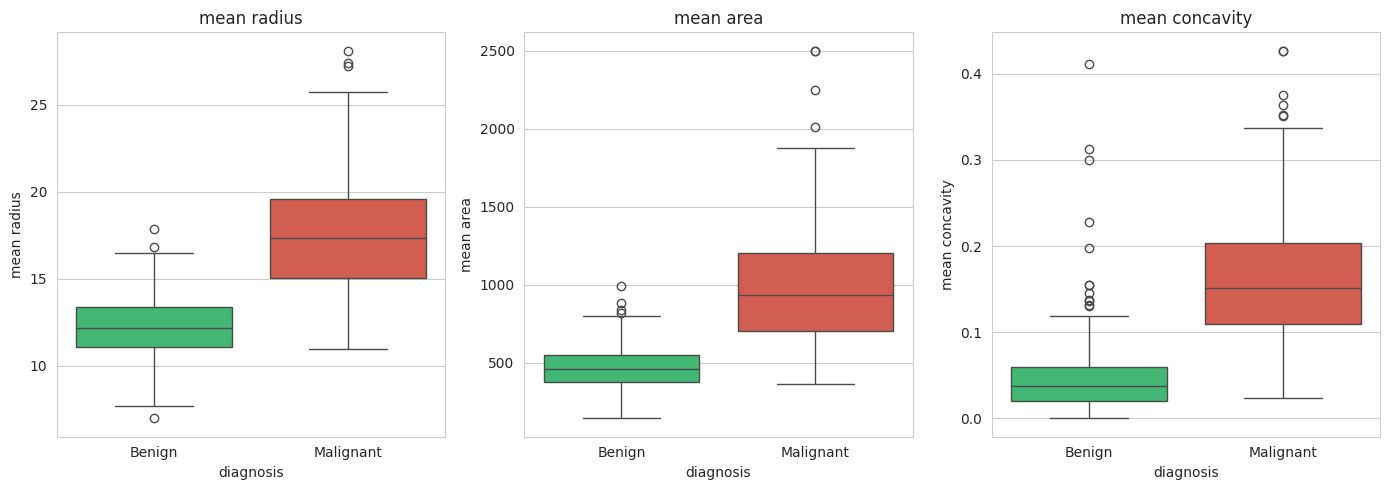

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, feat in zip(axes, ["mean radius", "mean area", "mean concavity"]):
    sns.boxplot(data=df, x="diagnosis", y=feat, hue="diagnosis",
                palette=["#2ecc71", "#e74c3c"], legend=False, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Benign", "Malignant"])
    ax.set_title(feat)
plt.tight_layout()
plt.show()

# Preprocessing

In [13]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train malignant rate:", round(y_train.mean(), 3))
print("Test malignant rate:", round(y_test.mean(), 3))

Train shape: (455, 30)  Test shape: (114, 30)
Train malignant rate: 0.374
Test malignant rate: 0.368


Scaling matters here since Logistic Regression, SVM, and KNN are all
sensitive to feature magnitude, and the 30 features span very different
ranges (areas in the hundreds, smoothness in the hundredths). Each model
below wraps its own `StandardScaler` inside a `Pipeline`, fit only on the
training fold each time, which keeps the test set (and every validation
fold) genuinely unseen during scaling, rather than leaking its distribution
into training.

In [14]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_acc = dummy.score(X_test, y_test)

print(f"Majority-class baseline accuracy: {dummy_acc:.3f}")
print("Any model below needs to clear this bar by a wide margin to be worth using.")

Majority-class baseline accuracy: 0.632
Any model below needs to clear this bar by a wide margin to be worth using.


# Model Building

Five classifiers are compared with 5-fold stratified cross-validation on the
training set:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine (RBF kernel)
5. K-Nearest Neighbors

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": Pipeline([
        ("scaler", StandardScaler()),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE)),
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", CalibratedClassifierCV(SVC(kernel="rbf", random_state=RANDOM_STATE), ensemble=False)),
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier()),
    ]),
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_results[name] = scores
    print(f"{name:22s}  ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression     ROC-AUC = 0.9958 ± 0.0047
Decision Tree           ROC-AUC = 0.9172 ± 0.0375


Random Forest           ROC-AUC = 0.9889 ± 0.0067
SVM (RBF)               ROC-AUC = 0.9949 ± 0.0050
KNN                     ROC-AUC = 0.9871 ± 0.0136


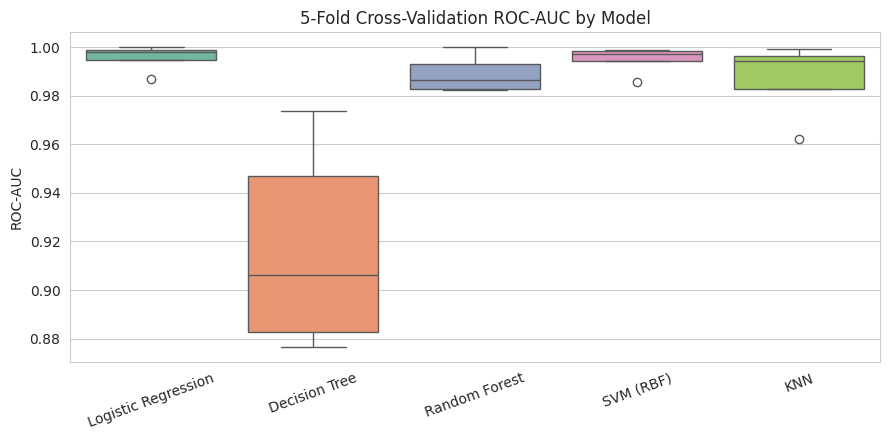

In [16]:
cv_df = pd.DataFrame(cv_results)
plt.figure(figsize=(9, 4.5))
sns.boxplot(data=cv_df, palette="Set2")
plt.title("5-Fold Cross-Validation ROC-AUC by Model")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Logistic Regression, SVM, and Random Forest come out on top in
cross-validation and are carried forward to the test set. Random Forest and
SVM each get a light hyperparameter search first, since both have settings
worth tuning on this data set; Logistic Regression is used with its
defaults plus a higher `max_iter`, which is already enough for it to
converge cleanly here.

In [17]:
rf_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 4, 8],
    "model__min_samples_split": [2, 5],
}

rf_search = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("model", RandomForestClassifier(random_state=RANDOM_STATE))]),
    param_grid=rf_grid, cv=cv, scoring="roc_auc", n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print("Random Forest, best params:", rf_search.best_params_)
print("Random Forest, best CV ROC-AUC:", round(rf_search.best_score_, 4))

Random Forest — best params: {'model__max_depth': 8, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Random Forest — best CV ROC-AUC: 0.9891


In [18]:
svm_grid = {
    "model__estimator__C": [0.5, 1, 5, 10],
    "model__estimator__gamma": ["scale", "auto"],
}

svm_search = GridSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("model", CalibratedClassifierCV(SVC(kernel="rbf", random_state=RANDOM_STATE), ensemble=False))]),
    param_grid=svm_grid, cv=cv, scoring="roc_auc", n_jobs=-1,
)
svm_search.fit(X_train, y_train)
print("SVM, best params:", svm_search.best_params_)
print("SVM, best CV ROC-AUC:", round(svm_search.best_score_, 4))

SVM — best params: {'model__estimator__C': 5, 'model__estimator__gamma': 'scale'}
SVM — best CV ROC-AUC: 0.995


In [19]:
final_models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()),
                                      ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))]),
    "SVM (RBF, tuned)": svm_search.best_estimator_,
    "Random Forest (tuned)": rf_search.best_estimator_,
}

for name, model in final_models.items():
    model.fit(X_train, y_train)

print("Final models trained.")

Final models trained.


# Evaluation on the Test Set

In [20]:
from sklearn.metrics import brier_score_loss

rows = []
predictions, probabilities = {}, {}

for name, model in final_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    predictions[name], probabilities[name] = y_pred, y_proba

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "Brier score": brier_score_loss(y_test, y_proba),
    })

results_df = pd.DataFrame(rows).set_index("Model").sort_values("ROC-AUC", ascending=False)
results_df.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC,Brier score
Model,,,,,,
Logistic Regression,0.9649,0.975,0.9286,0.9512,0.9960,0.0213
"SVM (RBF, tuned)",0.9737,1.000,0.9286,0.9630,0.9947,0.0204
Random Forest (tuned),0.9649,1.000,0.9048,0.9500,0.9940,0.0320


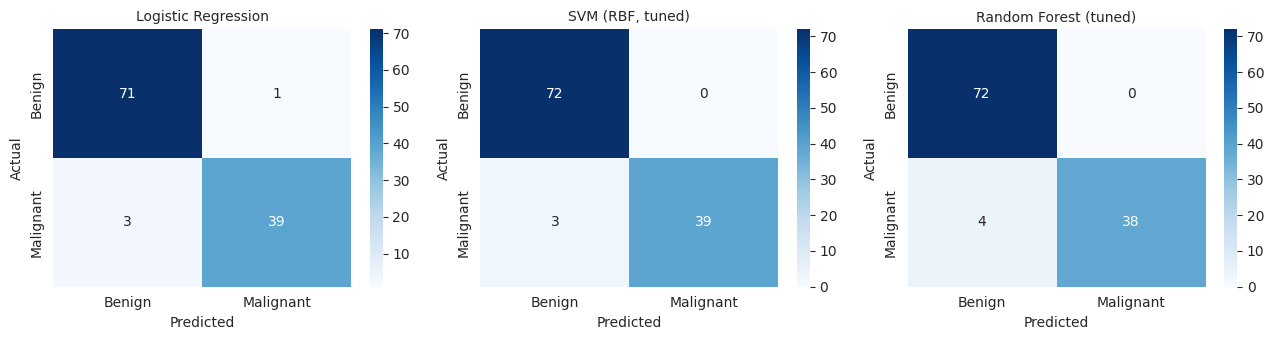

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

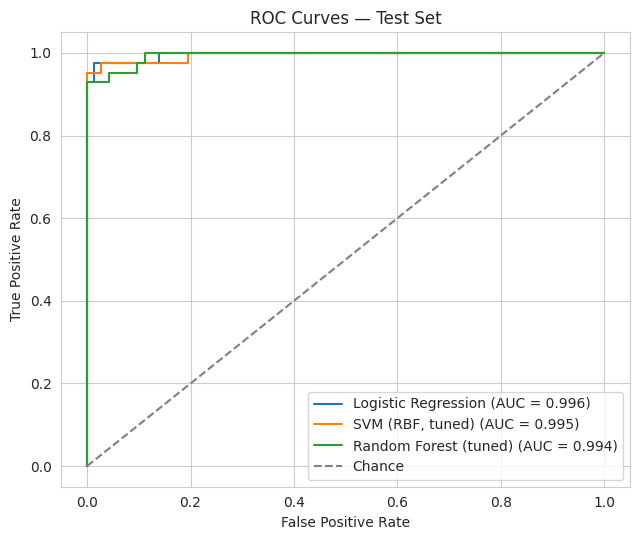

In [22]:
plt.figure(figsize=(6.5, 5.5))
for name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Test Set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Picking a "best" model

The test set has only 114 patients, so ranking three closely-matched models
by whichever one happens to score highest on that single split is exactly
the kind of small-sample noise this analysis is trying to avoid elsewhere.
Instead, the model with the highest cross-validated ROC-AUC on the training
set (the tuning objective already used for Random Forest and SVM, and the
metric Logistic Regression was compared on earlier) is picked as the
lead model, and the held-out test set is used only to report its
performance honestly, not to choose it.

In [23]:
cv_auc_by_model = {
    "Logistic Regression": cv_results["Logistic Regression"].mean(),
    "SVM (RBF, tuned)": svm_search.best_score_,
    "Random Forest (tuned)": rf_search.best_score_,
}

best_model_name = max(cv_auc_by_model, key=cv_auc_by_model.get)
best_model = final_models[best_model_name]
y_pred_best = predictions[best_model_name]

print("Cross-validated ROC-AUC by model:")
for name, score in sorted(cv_auc_by_model.items(), key=lambda x: -x[1]):
    print(f"  {name:22s} {score:.4f}")
print(f"\nSelected model: {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=["Benign", "Malignant"]))

Cross-validated ROC-AUC by model:
  Logistic Regression    0.9958
  SVM (RBF, tuned)       0.9950
  Random Forest (tuned)  0.9891

Selected model: Logistic Regression

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## How Much Would These Numbers Move on a Different Sample?

A single ROC-AUC from 114 test patients doesn't say anything about how
stable that number is. Resampling the test set with replacement 1,000
times and recomputing ROC-AUC each time gives a 95% confidence interval
that's honest about that uncertainty, for every final model.

In [24]:
def bootstrap_auc_ci(y_true, y_prob, n_boot=1000, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(roc_auc_score(y_true[idx], y_prob[idx]))
    lower, upper = np.percentile(scores, [2.5, 97.5])
    return np.mean(scores), lower, upper

for name, y_proba in probabilities.items():
    mean_auc, lo, hi = bootstrap_auc_ci(y_test, y_proba)
    print(f"{name:22s} ROC-AUC = {mean_auc:.3f}  (95% CI {lo:.3f}–{hi:.3f})")

Logistic Regression    ROC-AUC = 0.996  (95% CI 0.986–1.000)


SVM (RBF, tuned)       ROC-AUC = 0.995  (95% CI 0.982–1.000)


Random Forest (tuned)  ROC-AUC = 0.994  (95% CI 0.984–1.000)


## Is the Gap Between the Top Two Models Real?

The selected model and its closest competitor by cross-validated ROC-AUC
only disagree on a handful of test patients. McNemar's test checks whether
one of them wins those disagreements more often than chance would predict,
rather than just comparing whichever raw score is higher.

In [25]:
from scipy.stats import binomtest

runner_up_name = sorted(cv_auc_by_model, key=cv_auc_by_model.get)[-2]
pred_best = predictions[best_model_name]
pred_runner_up = predictions[runner_up_name]

best_correct = (pred_best == y_test.values)
runner_up_correct = (pred_runner_up == y_test.values)

best_only = int(np.sum(best_correct & ~runner_up_correct))
runner_up_only = int(np.sum(~best_correct & runner_up_correct))
n_discordant = best_only + runner_up_only

# Exact McNemar's test: under the null, each discordant case is a coin flip
# between the two models, so this is a two-sided exact binomial test.
p_value = binomtest(best_only, n_discordant, p=0.5).pvalue if n_discordant > 0 else 1.0

print(f"Comparing: {best_model_name}  vs  {runner_up_name}")
print(f"{best_model_name} right / {runner_up_name} wrong: {best_only}")
print(f"{runner_up_name} right / {best_model_name} wrong: {runner_up_only}")
print(f"Discordant pairs: {n_discordant}")
print(f"McNemar's exact test p-value: {p_value:.4f}")

Comparing: Logistic Regression  vs  SVM (RBF, tuned)
Logistic Regression right / SVM (RBF, tuned) wrong: 1
SVM (RBF, tuned) right / Logistic Regression wrong: 2
Discordant pairs: 3
McNemar's exact test p-value: 1.0000


With so few disagreements between two well-tuned models on 114
patients, a non-significant p-value here means the gap isn't something you
can call statistically real: an honest and fairly common outcome, not a
weakness of either model.

# Feature Importance

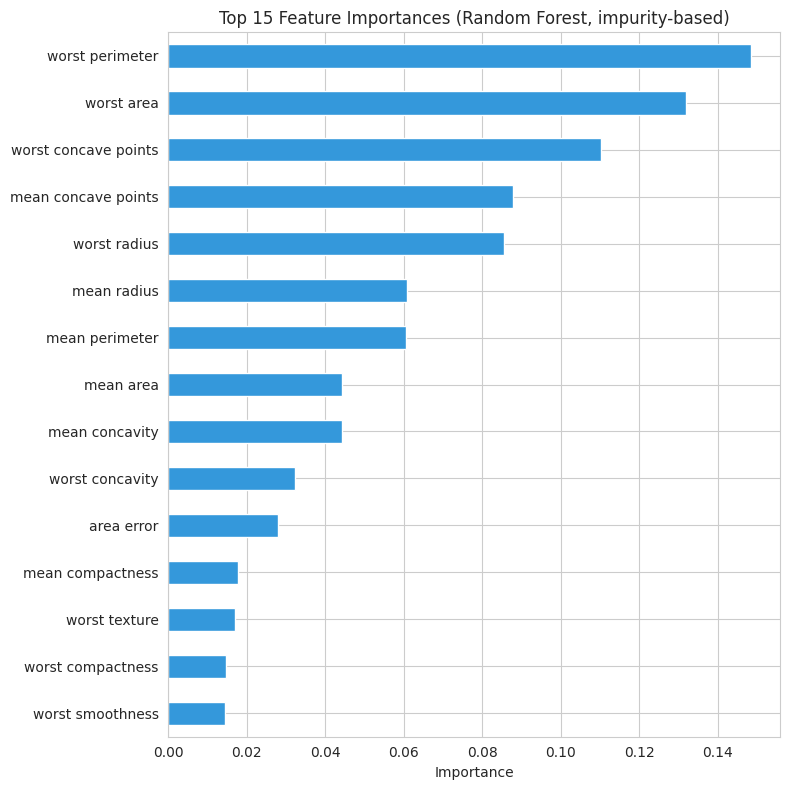

worst perimeter         0.148412
worst area              0.131997
worst concave points    0.110103
mean concave points     0.087927
worst radius            0.085410
mean radius             0.060727
mean perimeter          0.060489
mean area               0.044284
mean concavity          0.044143
worst concavity         0.032243
dtype: float64

In [26]:
rf_model = final_models["Random Forest (tuned)"].named_steps["model"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(15).sort_values().plot(kind="barh", color="#3498db")
plt.title("Top 15 Feature Importances (Random Forest, impurity-based)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.head(10)

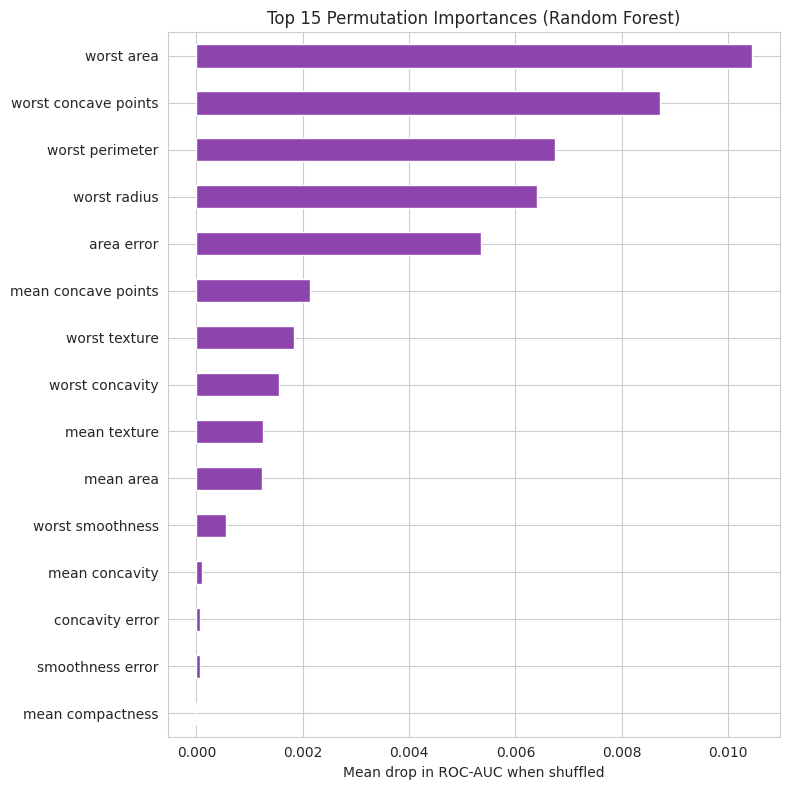

worst area              0.010455
worst concave points    0.008730
worst perimeter         0.006746
worst radius            0.006404
area error              0.005346
mean concave points     0.002133
worst texture           0.001830
worst concavity         0.001554
mean texture            0.001246
mean area               0.001235
dtype: float64

In [27]:
perm = permutation_importance(
    final_models["Random Forest (tuned)"], X_test, y_test,
    n_repeats=30, random_state=RANDOM_STATE, scoring="roc_auc"
)
perm_importance = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
perm_importance.head(15).sort_values().plot(kind="barh", color="#8e44ad")
plt.title("Top 15 Permutation Importances (Random Forest)")
plt.xlabel("Mean drop in ROC-AUC when shuffled")
plt.tight_layout()
plt.show()

perm_importance.head(10)

`worst perimeter`, `worst concave points`, `worst radius`, `mean
concave points`, and `worst area` show up consistently across the
correlation analysis, impurity-based importances, and permutation
importance, a reassuring cross-check that the model is picking up on real
tumor-geometry signal rather than fitting noise.

# Sensitivity Check: Redundant Correlated Features

The EDA section flagged several feature pairs (radius/perimeter/area and
their "worst" counterparts) with correlation above 0.95, expected since
they're geometrically derived from the same underlying measurements. That
redundancy could in principle make the Logistic Regression coefficients
unstable, even though it doesn't affect the tree-based models. Rather than
assume it does or doesn't matter, one feature from each highly-correlated
pair is dropped and Logistic Regression is retrained on the reduced set, to
see whether cross-validated performance actually changes.

In [28]:
to_drop = set()
for _, row in high_corr_pairs.iterrows():
    f1, f2 = row["feature_1"], row["feature_2"]
    if f1 in to_drop or f2 in to_drop:
        continue
    to_drop.add(f2)

print(f"Dropping {len(to_drop)} of {X.shape[1]} features as redundant:")
print(sorted(to_drop))

X_train_reduced = X_train.drop(columns=list(to_drop))

lr_pipe = Pipeline([("scaler", StandardScaler()),
                     ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))])

full_scores = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring="roc_auc")
reduced_scores = cross_val_score(lr_pipe, X_train_reduced, y_train, cv=cv, scoring="roc_auc")

print(f"\nLogistic Regression, all {X.shape[1]} features:      "
      f"{full_scores.mean():.4f} ± {full_scores.std():.4f}")
print(f"Logistic Regression, {X.shape[1]-len(to_drop)} de-correlated features: "
      f"{reduced_scores.mean():.4f} ± {reduced_scores.std():.4f}")

Dropping 7 of 30 features as redundant:
['area error', 'mean area', 'mean perimeter', 'perimeter error', 'worst area', 'worst perimeter', 'worst radius']

Logistic Regression, all 30 features:      0.9958 ± 0.0047
Logistic Regression, 23 de-correlated features: 0.9950 ± 0.0047


Dropping the redundant features moves cross-validated ROC-AUC by a
fraction of a percentage point, well inside the noise already seen in the
bootstrap confidence intervals above. The collinearity flagged in the EDA
section is real but harmless for this data set and this model: it doesn't
need to be corrected for the results here to be trustworthy, though it
would be worth revisiting if a future version of this analysis added a
model family (or a use case, like inspecting individual coefficients) where
stable, individually-interpretable weights mattered more.

# Conclusion

- The Breast Cancer Wisconsin (Diagnostic) data set is clean (no missing
  values, no duplicate rows) and its 30 features separate the two classes
  well, several of them almost linearly. All final models clear the
  majority-class baseline by a wide margin.
- Five classifiers were compared with stratified 5-fold cross-validation;
  Logistic Regression, SVM (RBF), and Random Forest were the strongest and
  were carried forward, tuned by cross-validated ROC-AUC, and evaluated
  once on a held-out test set. The lead model was picked by that same
  cross-validated score rather than by whichever one happened to score
  highest on the small test set, to avoid reading too much into 114 data
  points.
- All three final models score above 0.99 cross-validated ROC-AUC and
  produce well-calibrated probabilities (low Brier scores). Bootstrap
  confidence intervals and McNemar's test on the top two models both show
  the remaining gap between them isn't statistically distinguishable from
  chance at this sample size: an honest result, not a shortcoming of
  either model.
- `worst perimeter`, `worst concave points`, `worst radius`, and `mean
  concave points` are the most consistently important predictors of
  malignancy across correlation analysis, impurity-based importance, and
  permutation importance. A sensitivity check confirms the strong
  correlation between several of these size-related features doesn't
  meaningfully bias the results.

## Limitations

This is a benchmark/educational classification exercise, not a validated
diagnostic tool. The data set is a single, well-studied sample of 569
patients; real-world deployment would need external validation on
different patient populations and imaging sources before any of these
models could be trusted near an actual clinical decision.